# Importador de datos desde un PDF

## Bibliotecas necesarias

In [3]:
# Dependencies:
#
import pandas as pd
import numpy as np
import re
import PyPDF2
import seaborn as sns
import matplotlib.pyplot as plt

#
import warnings
warnings.filterwarnings('ignore')

In [4]:
#!pip install PyPDF2

In [ ]:
# Opciones de visualización de cifras:
#pd.options.display.float_format = '{:,.2f}'.format #'${:,.2f}'

In [ ]:
# Opciones de visualización de dataframes:
#pd.set_option('display.max_rows', 500)
#pd.set_option('display.max_columns', 500)
#pd.set_option('display.width', 1000)

# Información en PDF

### Importación y limpieza de datos

https://www.gob.mx/cne/documentos/precios-maximos-aplicables-de-gas-lp-399897

In [5]:
# Inicializar una lista para almacenar cada línea del PDF como un registro
datos = []

# Abrir el archivo PDF en modo binario
with open('PRECIOS_MA_XIMOS_VIGENTES_DEL_01_AL_07_DE_MARZO_DE_2026.pdf', 'rb') as archivo_pdf:
    lector_pdf = PyPDF2.PdfReader(archivo_pdf)
    # Iterar a través de cada página del PDF
    for pagina in lector_pdf.pages:
        # Extraer el texto de la página
        texto_pagina = pagina.extract_text()
        # Dividir el texto en líneas
        lineas = texto_pagina.split('\n')
                # Añadir cada línea a la lista de datos
        for linea in lineas:
            # Aquí podrías necesitar procesar cada línea si necesitas dividirla en columnas
            datos.append(linea)

#datos

In [6]:
#

datos

['Región Entidad Federativa MunicipioPrecio por ',
 'kilogramo con ',
 'IVAPrecio por ',
 'litro con ',
 'IVA',
 '1 Aguascalientes Aguascalientes $19.22 $10.38',
 '1 Aguascalientes Asientos $19.22 $10.38',
 '1 Aguascalientes El Llano $19.22 $10.38',
 '1 Aguascalientes Jesús María $19.22 $10.38',
 '1 Aguascalientes Pabellón de Arteaga $19.22 $10.38',
 '1 Aguascalientes San Francisco de los Romo $19.22 $10.38',
 '1 Aguascalientes San José de Gracia $19.22 $10.38',
 '1 Aguascalientes Tepezalá $19.22 $10.38',
 '1 Jalisco Villa Hidalgo $19.22 $10.38',
 '1 Zacatecas Villa García $19.22 $10.38',
 '2 Zacatecas Apozol $19.66 $10.62',
 '2 Zacatecas Atolinga $19.66 $10.62',
 '2 Zacatecas Benito Juárez $19.66 $10.62',
 '2 Zacatecas El Plateado de Joaquín Amaro $19.66 $10.62',
 '2 Zacatecas Huanusco $19.66 $10.62',
 '2 Zacatecas Jalpa $19.66 $10.62',
 '2 Zacatecas Juchipila $19.66 $10.62',
 '2 Zacatecas Mezquital del Oro $19.66 $10.62',
 '2 Zacatecas Momax $19.66 $10.62',
 '2 Zacatecas Moyahua de E

In [7]:
# Write a TXT file with data from PDF:

with open('Precios.txt', 'w') as f:
    for line in datos:
        f.write(line)
        f.write('\n')

In [8]:
# Iteremos en los datos para extraer solo los textos de interes

datos_clean = []

for element in datos:
    if re.search( r'^\d.*\$' , element):
        datos_clean.append( element )

#datos_clean

In [9]:
#

datos_clean

['1 Aguascalientes Aguascalientes $19.22 $10.38',
 '1 Aguascalientes Asientos $19.22 $10.38',
 '1 Aguascalientes El Llano $19.22 $10.38',
 '1 Aguascalientes Jesús María $19.22 $10.38',
 '1 Aguascalientes Pabellón de Arteaga $19.22 $10.38',
 '1 Aguascalientes San Francisco de los Romo $19.22 $10.38',
 '1 Aguascalientes San José de Gracia $19.22 $10.38',
 '1 Aguascalientes Tepezalá $19.22 $10.38',
 '1 Jalisco Villa Hidalgo $19.22 $10.38',
 '1 Zacatecas Villa García $19.22 $10.38',
 '2 Zacatecas Apozol $19.66 $10.62',
 '2 Zacatecas Atolinga $19.66 $10.62',
 '2 Zacatecas Benito Juárez $19.66 $10.62',
 '2 Zacatecas El Plateado de Joaquín Amaro $19.66 $10.62',
 '2 Zacatecas Huanusco $19.66 $10.62',
 '2 Zacatecas Jalpa $19.66 $10.62',
 '2 Zacatecas Juchipila $19.66 $10.62',
 '2 Zacatecas Mezquital del Oro $19.66 $10.62',
 '2 Zacatecas Momax $19.66 $10.62',
 '2 Zacatecas Moyahua de Estrada $19.66 $10.62',
 '2 Zacatecas Santa María de la Paz $19.66 $10.62',
 '2 Zacatecas Tabasco $19.66 $10.62',

In [10]:
# Iteremos en los datos para extraer solo los textos de interes

Texto     = []

Precio_Kg = []

Precio_Lt = []

for text in datos_clean:
    #
    match = re.search( r'^(.*?)\$([\d.]+) \$([\d.]+)', text)
    #
    Texto.append( match.group(1) )
    Precio_Kg.append( match.group(2) )
    Precio_Lt.append( match.group(3) )
#

In [11]:
# Creamos un Dataframe

DF_GasLP = pd.DataFrame( { 'Texto': Texto,
                           'Precio_Kg': Precio_Kg,
                           'Precio_Lt': Precio_Lt
                         } )

DF_GasLP

,Texto,Precio_Kg,Precio_Lt
0,1 Aguascalientes Aguascalientes,19.22,10.38
1,1 Aguascalientes Asientos,19.22,10.38
2,1 Aguascalientes El Llano,19.22,10.38
3,1 Aguascalientes Jesús María,19.22,10.38
4,1 Aguascalientes Pabellón de Arteaga,19.22,10.38
...,...,...,...
2473,219 Zacatecas Chalchihuites,19.22,10.38
2474,219 Zacatecas Jiménez del Teul,19.22,10.38
2475,219 Zacatecas Sain Alto,19.22,10.38
2476,219 Zacatecas Sombrerete,19.22,10.38


In [12]:
# Save into CSV:

DF_GasLP.to_csv( 'Precios.csv', encoding = 'UTF-8', index = False )

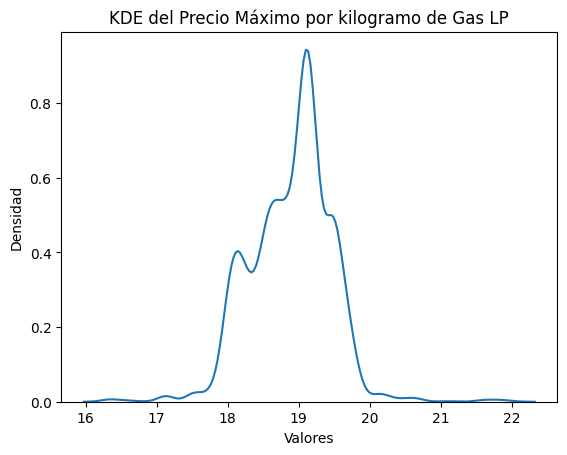

In [13]:
# Density Plots

# Crear un KDE para la columna 'data_column'
sns.kdeplot( DF_GasLP['Precio_Kg'].astype(float) )

# Añadir títulos y etiquetas según sea necesario
plt.title('KDE del Precio Máximo por kilogramo de Gas LP')
plt.xlabel('Valores')
plt.ylabel('Densidad')

# Mostrar el gráfico
plt.show()

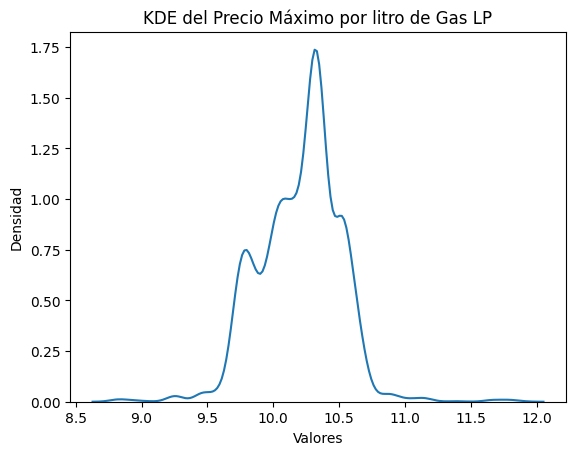

In [14]:
# Density Plots

# Crear un KDE para la columna 'data_column'
sns.kdeplot( DF_GasLP['Precio_Lt'].astype(float) )

# Añadir títulos y etiquetas según sea necesario
plt.title('KDE del Precio Máximo por litro de Gas LP')
plt.xlabel('Valores')
plt.ylabel('Densidad')

# Mostrar el gráfico
plt.show()